# iter_4 Macro Autoresearch Analysis

Validation CAGR is the selection objective subject to no ruin. Locked OOS and DBMF excess are diagnostics only.


In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
results = pd.read_csv(Path('results.tsv'), sep='\t')
numeric_cols = ['train_cagr', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr', 'excess_oos_cagr_vs_dbmf']
for col in numeric_cols:
    results[col] = pd.to_numeric(results[col], errors="coerce")
results['trial'] = range(1, len(results) + 1)
results['ruined_flag'] = results['ruined'].astype(str).str.lower().isin(['true', '1'])
eligible = results[(~results['ruined_flag']) & (results['validation_cagr'] > 0)].copy()
best = eligible.loc[eligible['validation_cagr'].idxmax()]
keeps = results[results['status'] == 'keep'].copy()
summary = pd.DataFrame([{'rows': len(results), 'keeps': len(keeps), 'ruined': int(results['ruined_flag'].sum()), 'best_idea_id': best['idea_id'], 'best_validation_cagr': best['validation_cagr'], 'best_train_cagr': best['train_cagr'], 'best_oos_cagr': best['oos_cagr'], 'best_benchmark_oos_cagr': best['benchmark_oos_cagr'], 'best_excess_oos_cagr_vs_dbmf': best['excess_oos_cagr_vs_dbmf']}])
summary


,rows,keeps,ruined,best_idea_id,best_validation_cagr,best_train_cagr,best_oos_cagr,best_benchmark_oos_cagr,best_excess_oos_cagr_vs_dbmf
0,85,10,0,067_sector_only_top_one_one_month_score_weighted,0.463617,0.100452,0.372834,0.175494,0.197339


In [2]:
recent20 = results.tail(20).copy()
recent_summary = pd.DataFrame([{
    'added_trials': len(recent20),
    'added_keeps': int((recent20['status'] == 'keep').sum()),
    'best_added_idea_id': recent20.loc[recent20['validation_cagr'].idxmax(), 'idea_id'],
    'best_added_validation_cagr': recent20['validation_cagr'].max(),
    'best_added_oos_cagr': recent20.loc[recent20['validation_cagr'].idxmax(), 'oos_cagr'],
}])
display(recent_summary)
recent20[['trial', 'idea_id', 'status', 'train_cagr', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr', 'excess_oos_cagr_vs_dbmf', 'ruined']]

,added_trials,added_keeps,best_added_idea_id,best_added_validation_cagr,best_added_oos_cagr
0,20,2,067_sector_only_top_one_one_month_score_weighted,0.463617,0.372834


,trial,idea_id,status,train_cagr,validation_cagr,oos_cagr,benchmark_oos_cagr,excess_oos_cagr_vs_dbmf,ruined
65,66,061_equity_sector_top_one_one_month_score_weig...,keep,0.067002,0.442277,0.539525,0.175494,0.364030,False
66,67,062_equity_sector_top_two_nineteen_day_score_w...,discard,-0.046810,0.293623,0.449245,0.175494,0.273751,False
67,68,063_equity_sector_top_two_twenty_two_day_score...,discard,0.071369,0.318630,0.530335,0.175494,0.354840,False
68,69,064_public_text_conservative_equity_sector_mom...,discard,0.085048,0.353175,0.473655,0.175494,0.298160,False
69,70,065_public_text_hawkish_uncertainty_equity_mom...,discard,0.085048,0.353174,0.472577,0.175494,0.297083,False
70,71,066_sector_only_top_two_one_month_score_weighted,discard,0.071618,0.357201,0.441422,0.175494,0.265927,False
71,72,067_sector_only_top_one_one_month_score_weighted,keep,0.100452,0.463617,0.372834,0.175494,0.197339,False
72,73,068_equity_sector_top_two_one_month_risk_cap_n...,discard,0.079830,0.321878,0.427805,0.175494,0.252311,False
73,74,069_equity_sector_top_two_twenty_six_day_score...,discard,0.061491,0.249103,0.582286,0.175494,0.406792,False
74,75,070_public_text_beige_activity_equity_sector_m...,discard,0.085048,0.353174,0.475732,0.175494,0.300238,False


In [3]:
display_cols = ['trial', 'idea_id', 'status', 'train_cagr', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr', 'excess_oos_cagr_vs_dbmf', 'ruined', 'description']
results.sort_values('validation_cagr', ascending=False)[display_cols].head(12)


,trial,idea_id,status,train_cagr,validation_cagr,oos_cagr,benchmark_oos_cagr,excess_oos_cagr_vs_dbmf,ruined,description
71,72,067_sector_only_top_one_one_month_score_weighted,keep,0.100452,0.463617,0.372834,0.175494,0.197339,False,"Top-1 21-day score-weighted ETF momentum, with..."
65,66,061_equity_sector_top_one_one_month_score_weig...,keep,0.067002,0.442277,0.539525,0.175494,0.364030,False,"Top-1 21-day score-weighted ETF momentum, with..."
79,80,075_equity_sector_top_one_one_month_trend_sixt...,discard,0.065473,0.357427,0.739757,0.175494,0.564262,False,"Top-1 21-day score-weighted ETF momentum, 63-d..."
70,71,066_sector_only_top_two_one_month_score_weighted,discard,0.071618,0.357201,0.441422,0.175494,0.265927,False,"Top-2 21-day score-weighted ETF momentum, with..."
64,65,055_public_text_gated_equity_sector_momentum,keep,0.085048,0.353175,0.483080,0.173875,0.309206,False,Top-two 21-day equity sector/style momentum wi...
68,69,064_public_text_conservative_equity_sector_mom...,discard,0.085048,0.353175,0.473655,0.175494,0.298160,False,Top-2 21-day score-weighted ETF momentum with ...
57,58,054_equity_sector_top_two_one_month_score_weig...,keep,0.085048,0.353174,0.470357,0.176411,0.293946,False,Top-two 21-day equity sector/style momentum we...
69,70,065_public_text_hawkish_uncertainty_equity_mom...,discard,0.085048,0.353174,0.472577,0.175494,0.297083,False,Top-2 21-day score-weighted ETF momentum with ...
74,75,070_public_text_beige_activity_equity_sector_m...,discard,0.085048,0.353174,0.475732,0.175494,0.300238,False,Top-2 21-day score-weighted ETF momentum with ...
77,78,073_equity_sector_top_two_one_month_halfpct_th...,discard,0.085048,0.353174,0.477331,0.175494,0.301836,False,"Top-2 21-day score-weighted ETF momentum, 0.5%..."


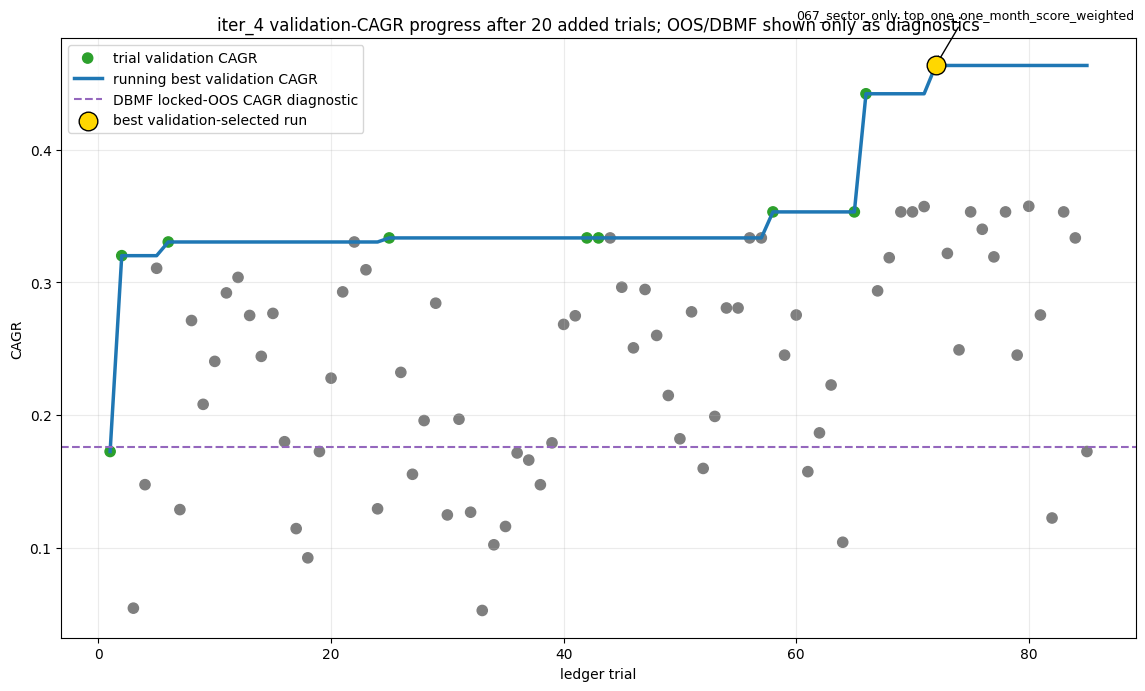

In [4]:
plot = results[['trial', 'idea_id', 'status', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr']].copy()
plot['running_best_validation_cagr'] = plot['validation_cagr'].where(~results['ruined_flag']).cummax()
fig, ax = plt.subplots(figsize=(12, 7))
colors = plot['status'].map({'keep': '#2ca02c', 'discard': '#7f7f7f', 'ruined': '#d62728', 'invalid_rationale': '#ff7f0e'}).fillna('#7f7f7f')
ax.scatter(plot['trial'], plot['validation_cagr'], c=colors, s=54, label='trial validation CAGR')
ax.plot(plot['trial'], plot['running_best_validation_cagr'], color='#1f77b4', linewidth=2.5, label='running best validation CAGR')
ax.axhline(float(best['benchmark_oos_cagr']), color='#9467bd', linestyle='--', linewidth=1.5, label='DBMF locked-OOS CAGR diagnostic')
ax.scatter([int(best['trial'])], [float(best['validation_cagr'])], color='gold', edgecolor='black', s=180, zorder=5, label='best validation-selected run')
ax.annotate(str(best['idea_id']), xy=(int(best['trial']), float(best['validation_cagr'])), xytext=(int(best['trial']) - 12, float(best['validation_cagr']) + 0.035), arrowprops={'arrowstyle': '->', 'color': 'black'}, fontsize=9)
ax.set_title('iter_4 validation-CAGR progress after 20 added trials; OOS/DBMF shown only as diagnostics')
ax.set_xlabel('ledger trial')
ax.set_ylabel('CAGR')
ax.grid(True, alpha=0.25)
ax.legend(loc='best')
fig.tight_layout()
fig.savefig('progress.png', dpi=180)
plt.show()


## Best run interpretation

The selected run is the highest non-ruined validation-CAGR strategy in the ledger. OOS CAGR and DBMF excess are locked diagnostics, not the selection criterion.


In [5]:
best[['idea_id', 'title', 'mechanism', 'expected_assets', 'feature_inputs', 'human_notes', 'train_cagr', 'validation_cagr', 'oos_cagr', 'benchmark_oos_cagr', 'excess_oos_cagr_vs_dbmf', 'ruined', 'status']].to_frame('best_run')


,best_run
idea_id,067_sector_only_top_one_one_month_score_weighted
title,Pure sector top-one one-month momentum
mechanism,Retail-accessible ETF momentum can persist bec...
expected_assets,XLK;XLY;XLC;XLI;XLF;XLV;XLP;XLU;XLE;SMH;SOXX;X...
feature_inputs,price_momentum_21d;score_weighted_top1
human_notes,"Top-1 21-day score-weighted ETF momentum, with..."
train_cagr,0.100452
validation_cagr,0.463617
oos_cagr,0.372834
benchmark_oos_cagr,0.175494


## Data quality, robustness, and anti-overfit audit

This section is intentionally user-facing. It gives a quick, auditable view of whether a candidate result is likely a fragile quant-research artifact:

- **Data quality:** first/last valid price dates, observation counts, missing counts, and longest missing streaks. Pre-inception gaps are visible instead of silently treated as zero returns.
- **Robustness:** parameter-neighborhood summaries should be read by median/p10/p90 and trial count, not by the single best validation row.
- **Anti-overfit:** trial count, family count, and best-minus-median validation performance show selection pressure. Locked OOS/DBMF diagnostics are for post-selection audit only.


In [6]:
from pathlib import Path

import pandas as pd

from datasets.quality import price_coverage_manifest
from research.overfit import selection_bias_summary
from research.robustness import summarize_robust_regions

artifact_paths = {
    "robustness": Path("robustness.tsv"),
    "overfit": Path("overfit_report.tsv"),
    "results": Path("results.tsv"),
}

try:
    from prepare import DEFAULT_UNIVERSE, load_prices
    prices = load_prices(DEFAULT_UNIVERSE)
    display(price_coverage_manifest(prices).sort_values(["longest_missing_streak", "missing_count"], ascending=False))
except Exception as exc:
    print(f"Price coverage manifest unavailable: {exc}")

if artifact_paths["robustness"].exists():
    robustness = pd.read_csv(artifact_paths["robustness"], sep="\t")
    group_columns = [column for column in ["universe_name", "lookback_days", "top_n", "score_weighted", "risk_cap"] if column in robustness.columns]
    if group_columns:
        display(summarize_robust_regions(robustness, group_columns).head(20))
else:
    print("robustness.tsv not found yet. Generate it with research.robustness.run_robustness_grid and write_robustness_tsv.")

if artifact_paths["results"].exists():
    results = pd.read_csv(artifact_paths["results"], sep="\t")
    display(pd.DataFrame([selection_bias_summary(results)]))
else:
    print("results.tsv not found yet. Anti-overfit summary will appear after experiment rows exist.")


,symbol,first_valid_date,last_valid_date,observations,missing_count,longest_missing_streak
17,beige_beige_activity_score,2026-01-15,2026-05-29,93,1682,1682
18,beige_beige_labor_score,2026-01-15,2026-05-29,93,1682,1682
19,beige_beige_price_pressure_score,2026-01-15,2026-05-29,93,1682,1682
20,beige_beige_token_count,2026-01-15,2026-05-29,93,1682,1682
24,sec_sec_10k_count,2025-10-30,2026-05-29,145,1630,1630
25,sec_sec_10q_count,2025-10-30,2026-05-29,145,1630,1630
26,sec_sec_8k_count,2025-10-30,2026-05-29,145,1630,1630
27,sec_sec_filing_count,2025-10-30,2026-05-29,145,1630,1630
21,fomc_hawkish_minus_dovish,2021-01-28,2026-05-29,1340,435,435
22,fomc_token_count,2021-01-28,2026-05-29,1340,435,435


robustness.tsv not found yet. Generate it with research.robustness.run_robustness_grid and write_robustness_tsv.


,trial_count,family_count,best_idea_id,best_validation_cagr,median_validation_cagr,best_minus_median_validation_cagr,median_oos_cagr,selection_bias_warning
0,85,55,067_sector_only_top_one_one_month_score_weighted,0.463617,0.271259,0.192358,0.49172,High trial counts inflate the best validation ...


## Public data artifact and feature-usage audit

These cells make the text/macro-data path auditable: the manifest shows which public artifacts were created, and the ledger display checks whether non-price feature claims produced parseable usage lines.

In [7]:
manifest_path = Path.home() / '.cache' / 'macroresearch' / 'iter_4' / 'artifact_manifest.tsv'
if manifest_path.exists():
    manifest = pd.read_csv(manifest_path, sep='\t')
    display(manifest[['dataset', 'row_count', 'artifact_path', 'sha256', 'point_in_time_safe']])
else:
    print(f'needs_data: missing artifact manifest at {manifest_path}')


,dataset,row_count,artifact_path,sha256,point_in_time_safe
0,prices_yahoo,8390,/Users/nyp/.cache/macroresearch/iter_4/market/...,3f6daaf7221b9773e500ee14e1f1f2f06586e7cee59bde...,True
1,prices_yahoo,6848,/Users/nyp/.cache/macroresearch/iter_4/market/...,ae645a2793835b924708da902360b8002ff249580529c7...,True
2,prices_yahoo,5807,/Users/nyp/.cache/macroresearch/iter_4/market/...,a9fd34d5c69a6904a23d75d3492c0c6279608aacf472c0...,True
3,prices_yahoo,6540,/Users/nyp/.cache/macroresearch/iter_4/market/...,25e75d9b2388c5a570bcec934869410c3cbafdb9bb9394...,True
4,prices_yahoo,3672,/Users/nyp/.cache/macroresearch/iter_4/market/...,20f6bae17695f0a904eea88c98c156d8f1421aa14c9261...,True
5,prices_yahoo,3236,/Users/nyp/.cache/macroresearch/iter_4/market/...,95e06d3f2a04c6a2703f1943431d5acc5f58ede85b2d4c...,True
6,prices_yahoo,3299,/Users/nyp/.cache/macroresearch/iter_4/market/...,f9f721cfce287613b4987012199ce3101e969c21bdc7b8...,True
7,prices_yahoo,3299,/Users/nyp/.cache/macroresearch/iter_4/market/...,a4ed088353e1f9f256d7fad4f120eb99869c9383535870...,True
8,prices_yahoo,5997,/Users/nyp/.cache/macroresearch/iter_4/market/...,2977e80dcdff8aaf42ae7b959e49880c4883e2042fb714...,True
9,prices_yahoo,5997,/Users/nyp/.cache/macroresearch/iter_4/market/...,5498507ee6b45f7f2257ba5878298a8ad93a3deb6ffae6...,True


In [8]:
usage_rows = results[results['description'].fillna('').str.contains('feature_usage_columns:', regex=False)].copy()
usage_display_cols = [column for column in ['trial', 'idea_id', 'status', 'feature_inputs', 'validation_cagr', 'description'] if column in usage_rows.columns]
if usage_rows.empty:
    print('No public feature usage rows found.')
else:
    display(usage_rows[usage_display_cols].tail(10))


,idea_id,status,feature_inputs,validation_cagr,description
75,071_equity_sector_top_two_one_month_equal_weight,discard,price_momentum_21d;score_equal_weight_top2,0.340083,"Top-2 21-day equal-weight ETF momentum, with S..."
76,072_equity_sector_top_three_one_month_score_we...,discard,price_momentum_21d;score_weighted_top3,0.319245,"Top-3 21-day score-weighted ETF momentum, with..."
77,073_equity_sector_top_two_one_month_halfpct_th...,discard,price_momentum_21d;score_weighted_top2;price_m...,0.353174,"Top-2 21-day score-weighted ETF momentum, 0.5%..."
78,074_equity_sector_top_two_one_month_trend_sixt...,discard,price_momentum_21d;score_weighted_top2;trend_f...,0.245156,"Top-2 21-day score-weighted ETF momentum, 63-d..."
79,075_equity_sector_top_one_one_month_trend_sixt...,discard,price_momentum_21d;score_weighted_top1;trend_f...,0.357427,"Top-1 21-day score-weighted ETF momentum, 63-d..."
80,076_technology_growth_top_two_one_month_score_...,discard,price_momentum_21d;score_weighted_top2,0.275412,"Top-2 21-day score-weighted ETF momentum, with..."
81,077_quality_defensive_top_two_one_month_score_...,discard,price_momentum_21d;score_weighted_top2,0.122311,"Top-2 21-day score-weighted ETF momentum, with..."
82,078_public_text_sec_calm_equity_sector_momentum,discard,price_momentum_21d;score_weighted_top2;fomc_ha...,0.353174,Top-2 21-day score-weighted ETF momentum with ...
83,079_full_macro_top_two_one_month_score_weighted,discard,price_momentum_21d;score_weighted_top2,0.333551,"Top-2 21-day score-weighted ETF momentum, with..."
84,080_equity_sector_top_two_blended_score_weighted,discard,price_blended_3_6_12_month_momentum;score_weig...,0.172452,"Top-2 21-day score-weighted ETF momentum, blen..."
